PRAKTIKUM INVERSI WEEK 3

NON WEIGHTED

[[1.  0.  0.  0. ]
 [0.  1.  0.  0. ]
 [0.  0.  1.  0. ]
 [0.  0.  0.  0.1]]


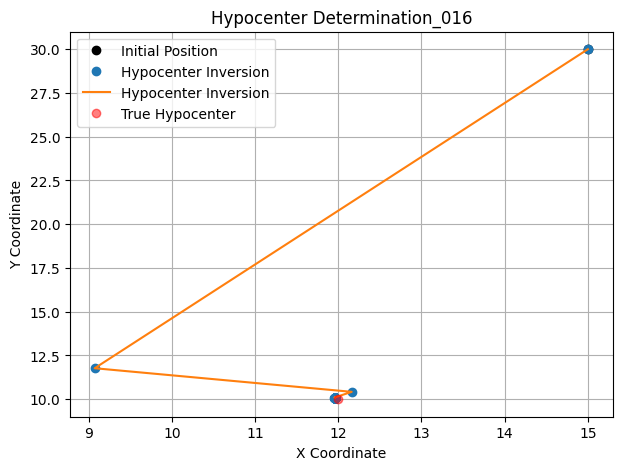

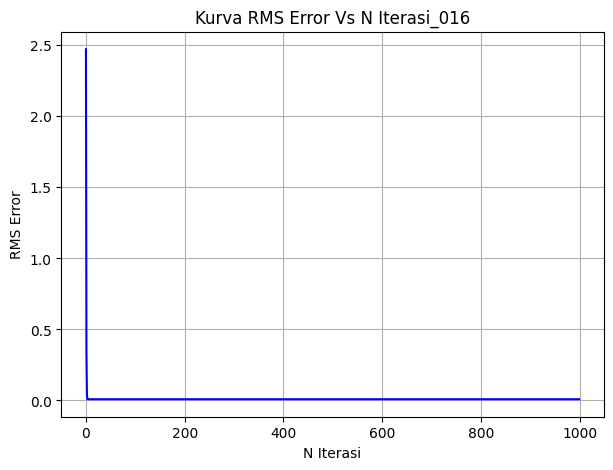

[np.float64(2.4719581518191958), np.float64(0.35024523812940705), np.float64(0.03927621064445847), np.float64(0.008936553572522358), np.float64(0.008925744654488551), np.float64(0.008925744636679033), np.float64(0.008925744636678924), np.float64(0.008925744636679011), np.float64(0.008925744636678818), np.float64(0.008925744636678837), np.float64(0.008925744636678837), np.float64(0.008925744636678837), np.float64(0.008925744636678837), np.float64(0.008925744636678837), np.float64(0.008925744636678837), np.float64(0.008925744636678837), np.float64(0.008925744636678837), np.float64(0.008925744636678837), np.float64(0.008925744636678837), np.float64(0.008925744636678837), np.float64(0.008925744636678837), np.float64(0.008925744636678837), np.float64(0.008925744636678837), np.float64(0.008925744636678837), np.float64(0.008925744636678837), np.float64(0.008925744636678837), np.float64(0.008925744636678837), np.float64(0.008925744636678837), np.float64(0.008925744636678837), np.float64(0.0089

In [ ]:
#Inversi Least Squares
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import copy
from numpy.linalg import inv

# Station Position
x = [0, 10, 20,30]                                                        # Koordinat X stasiun
z = [0, 0, 0, 0]                                                          # Koordinat Z stasiun (kedalaman)
n = len(x)                                                                # Jumlah stasiun

# True hypocenter
x0 = 12                                                                   # Koordinat X hiposenter sebenarnya
z0 = 10                                                                   # Koordinat Z hiposenter sebenarnya (kedalaman)
t0 = 0                                                                    # Waktu origin gempa

# Model Velocity 1 Layer
v = 7                                                                     # Kecepatan gelombang seismik (km/s)

# Forward Modelling untuk menghitung waktu tempuh dari hiposenter ke stasiun
t = []                                                                    # List untuk menyimpan waktu tempuh
for i in range(n):
  t.append((1/v) * np.sqrt((z[i] - z0)**2 + (x[i] - x0)**2))              # Rumus waktu tempuh: t = (1/v)*sqrt((z-z0)^2 + (x-x0)^2)

# Convert t menjadi numpy array
t = np.array(t)                                                           # Mengubah list waktu tempuh menjadi numpy array

# Menambahkan noise pada data travel time
noise = np.random.rand(n) * 0.03 * np.mean(t)                             # Membuat noise acak sebesar 3% dari rata-rata waktu tempuh
ti = t + noise                                                            # Data waktu tempuh observasi (travel time + noise)

# Tebakan awal posisi hiposenter
M = [15,30]                                                               # Tebakan awal posisi hiposenter (X,Z)
init_position = copy.deepcopy(M)                                          # Menyimpan posisi awal untuk plotting
M1 = []                                                                   # List untuk menyimpan estimasi hiposenter

# Membuat matriks bobot
W = np.eye(n)                                                             # Matriks identitas berukuran n x n

# Menentukan bobot
W[n-1][n-1] = 0.1                                                         # Mengurangi bobot data pada stasiun terakhir
# W[i][i] = abs(ti[i] - (ti[i] = np.mean(ti)))

print(W)

xhipo = [init_position[0]]                                                # Menyimpan koordinat X hiposenter hasil estimasi
yhipo = [init_position[1]]                                                # Menyimpan koordinat Z hiposenter hasil estimasi
Erms = []                                                                 # Menyimpan nilai RMS error pada setiap iterasi

# Proses inversi tanpa faktor bobot
for niter in range(1000):                                                 # Jumlah iterasi inversi
   gm = []                                                                # Waktu tempuh hasil perhitungan dari model saat ini
   dgm_dm1 = []                                                           # Turunan parsial waktu tempuh terhadap koordinat X
   dgm_dm2 = []                                                           # Turunan parsial waktu tempuh terhadap koordinat Z

   for i in range(n):
    gm.append(t0 + (1/v) * (np.sqrt((x[i] - M[0])**2 +(z[i] - M[1])**2))) # Menghitung waktu tempuh dari model hiposenter saat ini
    dgm_dm1.append((1/v) * (-1*(x[i] - M[0]))/(np.sqrt((x[i] - M[0])**2 +(z[i] - M[1])**2))) # Turunan terhadap X
    dgm_dm2.append((1/v) * (-1*(z[i] - M[1]))/(np.sqrt((x[i] - M[0])**2 +(z[i] - M[1])**2))) # Turunan terhadap Z

   J = np.zeros((n, 2))                                                   # Matriks Jacobian (jumlah data x jumlah parameter)

   for i in range(n):
     J[i][0] = dgm_dm1[i].item()                                          # Kolom pertama Jacobian (turunan terhadap X)
     J[i][1] = dgm_dm2[i].item()                                          # Kolom kedua Jacobian (turunan terhadap Z)

   Mo = copy.deepcopy(M)                                                  # Menyimpan model hiposenter saat ini

   # Menambahkan perturbasi model dari hasil inversi
   Mo = np.reshape(Mo, (2,1))                                             # Mengubah model menjadi vektor kolom (2 x 1)
   ti = np.reshape(ti, (n,1))                                             # Data observasi menjadi vektor kolom (n x 1)
   gm = np.reshape(gm, (n,1))                                             # Data model menjadi vektor kolom (n x 1)

   Model = Mo + inv(J.T @ J) @ J.T @ (ti - gm)                            # Persamaan inversi metode least squares
   M = [Model[0][0], Model[1][0]]                                         # Memperbarui model hiposenter

   Data = Model.tolist()                                                  # Mengubah hasil model menjadi list
   xhipo.append(Data[0][0])                                               # Menyimpan estimasi koordinat X
   yhipo.append(Data[1][0])                                               # Menyimpan estimasi koordinat Z

   # Menghitung RMS error
   dt = ti - gm                                                           # Selisih antara data observasi dan data model
   Erms.append(np.sqrt(np.average(dt**2)))                                # Perhitungan RMS error

plt.figure(figsize=(7,5))                                                 # Membuat grafik hasil inversi hiposenter
plt.plot(15, 30, 'o', label='Initial Position', color='black')            # Posisi awal hiposenter
plt.plot(xhipo, yhipo, 'o', label='Hypocenter Inversion')                 # Titik hasil iterasi inversi
plt.plot(xhipo, yhipo, '-', label='Hypocenter Inversion')                 # Jalur iterasi hiposenter
plt.plot(x0, z0, 'o', alpha=0.5, color='red', label='True Hypocenter')    # Posisi hiposenter sebenarnya
plt.title('Hypocenter Determination_016')                                 # Judul grafik
plt.xlabel('X Coordinate')                                                # Label sumbu X
plt.ylabel('Y Coordinate')                                                # Label sumbu Y
plt.legend()                                                              # Menampilkan legenda
plt.grid()                                                                # Menampilkan grid
plt.show()                                                                # Menampilkan grafik

# Plot kurva RMS error terhadap iterasi
plt.figure(figsize=(7,5))                                                 # Membuat grafik RMS error
plt.plot(Erms, color='blue')                                              # Kurva RMS error terhadap iterasi
plt.title('Kurva RMS Error Vs N Iterasi_016')                             # Judul grafik
plt.ylabel('RMS Error')                                                   # Label sumbu Y
plt.xlabel('N Iterasi')                                                   # Label sumbu X
plt.grid()                                                                # Menampilkan grid
plt.show()                                                                # Menampilkan grafik

print(Erms)                                                               # Menampilkan nilai RMS error setiap iterasi

WEIGHTED

[[1.  0.  0.  0. ]
 [0.  1.  0.  0. ]
 [0.  0.  1.  0. ]
 [0.  0.  0.  0.1]]


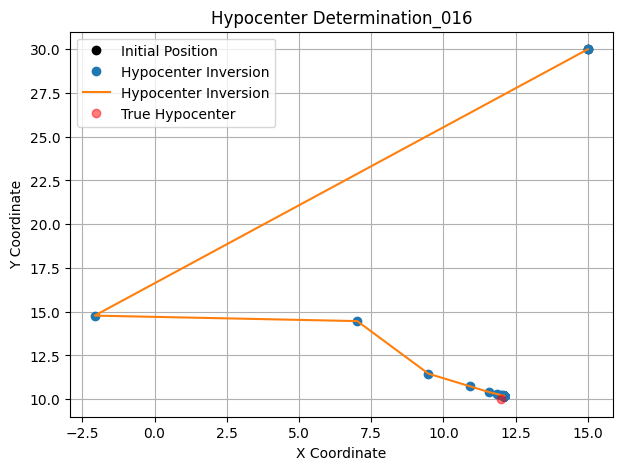

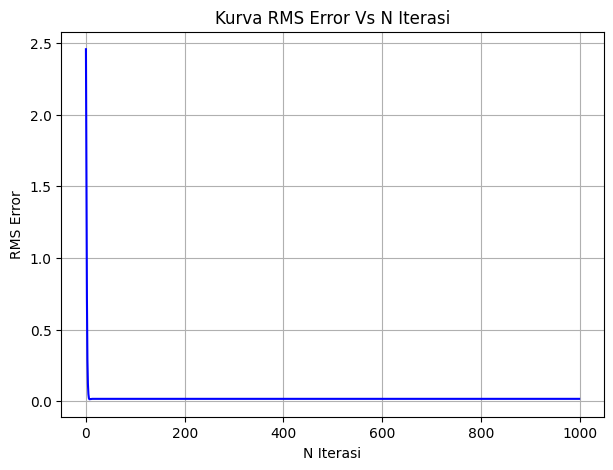

[np.float64(2.456238870569207), np.float64(1.5544504143553637), np.float64(0.7224898188752051), np.float64(0.2897681462890215), np.float64(0.12201449579124142), np.float64(0.050296732382235886), np.float64(0.021706450860519633), np.float64(0.014633104900729036), np.float64(0.015125972071032376), np.float64(0.016148191398828327), np.float64(0.01673370030844982), np.float64(0.017016976529595315), np.float64(0.017147249164253316), np.float64(0.01720602551984566), np.float64(0.017232335691730657), np.float64(0.017244072992433173), np.float64(0.017249301350175834), np.float64(0.01725162877751051), np.float64(0.01725266453952503), np.float64(0.01725312541903699), np.float64(0.017253330483182863), np.float64(0.017253421722264073), np.float64(0.017253462316756077), np.float64(0.01725348037814354), np.float64(0.01725348841403603), np.float64(0.017253491989370862), np.float64(0.017253493580110135), np.float64(0.017253494287862665), np.float64(0.01725349460275609), np.float64(0.017253494742858616

In [4]:
import pandas as pd               # Library untuk pengolahan data tabel
import numpy as np                # Library utama untuk operasi numerik dan matriks
import matplotlib.pyplot as plt   # Library untuk membuat grafik
import copy                       # Digunakan untuk menyalin variabel tanpa mengubah aslinya
from numpy.linalg import inv      # Fungsi untuk menghitung invers matriks
np.mat = np.asmatrix              # Mengubah array numpy menjadi format matriks

# Station Position
x = [0, 10, 20,30]                # Koordinat x stasiun seismik
z = [0, 0, 0, 0]                  # Koordinat z stasiun (semua di permukaan)
n = len(x)                        # Jumlah stasiun

# True hypocenter
x0 = 12                           # Posisi sebenarnya hiposenter pada arah x
z0 = 10                           # Kedalaman sebenarnya hiposenter
t0 = 0                            # Origin time gempa

# Model Velocity 1 Layer
v = 7                             # Kecepatan gelombang seismik (km/s)

# Forward Modelling untuk menghitung waktu tempuh dari hiposenter ke stasiun
t = []                            # List kosong untuk menyimpan travel time
for i in range(n):                # Loop untuk setiap stasiun
  t.append((1/v) * np.sqrt((z[i] - z0)**2 + (x[i] - x0)**2)) # rumus travel time

# Mengubah list travel time menjadi numpy array
t = np.array(t)

# Menambahkan noise (error) pada data travel time
noise = np.random.rand(n) * 0.03 * np.mean(t)  # noise acak sebesar 3% dari rata-rata waktu
ti = t + noise                                 # data observasi (travel time + noise)

# Tebakan awal posisi hiposenter
M = [15,30]                       # model awal (x,z)
init_position = copy.deepcopy(M)  # menyimpan posisi awal untuk plotting
M1 = []                           # variabel kosong (tidak dipakai lagi)

# Membuat matriks bobot
W = np.eye(n)                     # matriks identitas n x n

# Mengubah bobot data terakhir
W[n-1][n-1] = 0.1                 # data terakhir dianggap kurang akurat sehingga bobotnya kecil

print(W)                          # menampilkan matriks bobot

# Menyimpan posisi hiposenter setiap iterasi
xhipo = [init_position[0]]        # menyimpan koordinat x hasil inversi
yhipo = [init_position[1]]        # menyimpan koordinat z hasil inversi
Erms = []                         # menyimpan nilai RMS error tiap iterasi

# Proses inversi (iterasi)
for niter in range(1000):         # jumlah iterasi inversi
   gm = []                        # travel time hasil model
   dgm_dm1 = []                   # turunan travel time terhadap parameter x
   dgm_dm2 = []                   # turunan travel time terhadap parameter z

   for i in range(n):             # loop untuk setiap stasiun
    gm.append(t0 + (1/v) * (np.sqrt((x[i] - M[0])**2 +(z[i] - M[1])**2)))  # forward model travel time
    dgm_dm1.append((1/v) * (-1*(x[i] - M[0]))/(np.sqrt((x[i] - M[0])**2 +(z[i] - M[1])**2))) # turunan parsial terhadap x
    dgm_dm2.append((1/v) * (-1*(z[i] - M[1]))/(np.sqrt((x[i] - M[0])**2 +(z[i] - M[1])**2))) # turunan parsial terhadap z

   J = np.zeros((n, 2))           # membuat matriks Jacobian (jumlah data x jumlah parameter)

   for i in range(n):
     J[i][0] = dgm_dm1[i].item()  # kolom pertama Jacobian (turunan terhadap x)
     J[i][1] = dgm_dm2[i].item()  # kolom kedua Jacobian (turunan terhadap z)

   Mo = copy.deepcopy(M)          # menyimpan model lama

   # Mengubah bentuk menjadi matriks
   Mo = np.reshape(Mo, (2,1))     # model menjadi matriks 2x1
   ti = np.reshape(ti, (n,1))     # data observasi menjadi matriks nx1
   gm = np.reshape(gm, (n,1))     # data model menjadi matriks nx1

   # Persamaan inversi least squares berbobot
   Model = np.mat(Mo) + np.mat(inv(np.mat(J).transpose() * np.mat(J))) * np.mat(J.transpose()) * np.mat(W) * (np.mat(ti) - np.mat(gm))

   M = [Model[0][0], Model[1][0]] # memperbarui model hiposenter (x,z)

   Data = Model.tolist()          # mengubah matriks model menjadi list
   xhipo.append(Data[0][0])       # menyimpan koordinat x tiap iterasi
   yhipo.append(Data[1][0])       # menyimpan koordinat z tiap iterasi

   # Menghitung RMS error
   dt = ti - gm                   # selisih data observasi dan data model
   Erms.append(np.sqrt(np.average(dt**2))) # RMS error

# Plot posisi hiposenter hasil inversi
plt.figure(figsize=(7,5))
plt.plot(15, 30, 'o', label='Initial Position', color='black') # posisi tebakan awal
plt.plot(xhipo, yhipo, 'o', label='Hypocenter Inversion')      # titik iterasi hiposenter
plt.plot(xhipo, yhipo, '-', label='Hypocenter Inversion')      # jalur iterasi hiposenter
plt.plot(x0, z0, 'o', alpha=0.5, color='red', label='True Hypocenter') # posisi hiposenter sebenarnya
plt.title('Hypocenter Determination_016')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.legend()
plt.grid()

# Plot RMS error terhadap iterasi
plt.figure(figsize=(7,5))
plt.plot(Erms, color='blue')      # grafik RMS error
plt.title('Kurva RMS Error Vs N Iterasi')
plt.ylabel('RMS Error')
plt.xlabel('N Iterasi')
plt.grid()
plt.show()                        # menampilkan grafik

print(Erms)                       # menampilkan nilai RMS error setiap iterasi